In [1]:
##################### Modify Model Inputs #######################
# Super simple script to load in different netCDFs of model 
# inputs so they can be modified in a very simple way, then
# save the updated version as a new input netCDF to be used.
# The purpose of this is to test different settings and things
# in the model (AKA why are there lines...?)
#
# Notes: 
# - 
#
##################################################################

In [43]:
# Load in the modules
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import xroms

### <span style="color:mediumturquoise"> Bathymetry / The Grid </span>

In [3]:
# Load in the grid file
og_grid = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet_updated/Include/grd_500m_span_300km_002.nc')

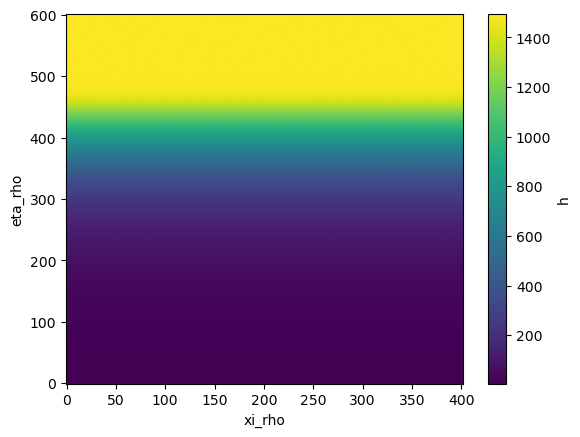

In [4]:
# Plot the original bathymetry
og_grid.h.plot()

In [5]:
# Make a new array that is constant bathymetry but same
# shape as OG
# 20 m constant 
new_const_bathy = np.full_like(og_grid.h, 20.0)

In [6]:
# Make a copy of the grid file
new_grid = og_grid.copy()

In [7]:
new_grid.h

<xarray.DataArray 'h' (eta_rho: 602, xi_rho: 402)> Size: 2MB
array([[   5.013698,    4.996944,    5.01793 , ...,    4.997116,    4.990096,
           5.020922],
       [   5.531654,    5.494657,    5.543554, ...,    5.506051,    5.537651,
           5.521313],
       [   5.940434,    5.941489,    5.974247, ...,    5.975286,    5.934504,
           5.935868],
       ...,
       [1483.484922, 1484.942742, 1488.565652, ..., 1492.997973, 1489.862877,
        1484.756018],
       [1482.111928, 1487.838183, 1494.128785, ..., 1484.634598, 1480.780838,
        1486.501802],
       [1492.794129, 1491.133894, 1488.368446, ..., 1488.753811, 1493.742186,
        1485.175239]])
Dimensions without coordinates: eta_rho, xi_rho

In [8]:
# Set the new bathymetry
new_grid['h'].values = new_const_bathy

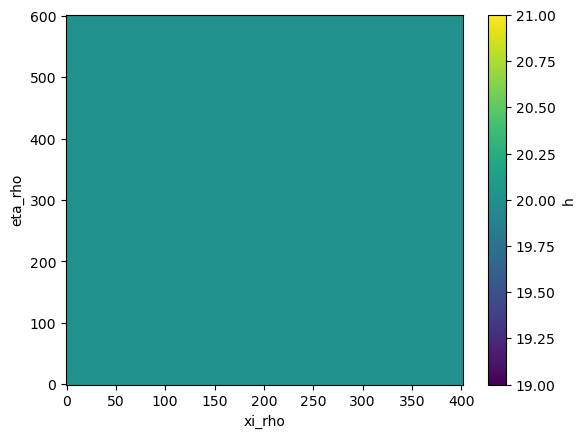

In [9]:
# Plot to see if it worked
new_grid.h.plot()

In [18]:
# Save to a new netCDF
#new_grid.to_netcdf('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet_updated/Include/grd_500m_span_300km_002_constbathy.nc')

### <span style="color:olivedrab"> Initial Conditions </span>

In [10]:
# Load in the initial conditions to be modified
# 500 m, span 300 km, based on make_ini.py
og_ini = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet_updated/Include/ini_ice_500m_span_300km_004.nc')

/tmp/ipykernel_1628819/1833349835.py:3: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  og_ini = xr.open_dataset('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet_updated/Include/ini_ice_500m_span_300km_004.nc')


In [11]:
# See what all is in here
og_ini

<xarray.Dataset> Size: 420MB
Dimensions:             (s_rho: 40, eta_rho: 602, xi_rho: 402, ocean_time: 1,
                         eta_u: 602, xi_u: 401, eta_v: 601, xi_v: 402)
Coordinates:
  * s_rho               (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * xi_rho              (xi_rho) int64 3kB 0 1 2 3 4 5 ... 397 398 399 400 401
  * eta_rho             (eta_rho) int64 5kB 0 1 2 3 4 5 ... 597 598 599 600 601
  * ocean_time          (ocean_time) timedelta64[ns] 8B 00:00:00
Dimensions without coordinates: eta_u, xi_u, eta_v, xi_v
Data variables: (12/22)
    temp                (s_rho, eta_rho, xi_rho) float64 77MB ...
    salt                (s_rho, eta_rho, xi_rho) float64 77MB ...
    u                   (ocean_time, s_rho, eta_u, xi_u) float64 77MB ...
    v                   (ocean_time, s_rho, eta_v, xi_v) float64 77MB ...
    zeta                (ocean_time, eta_rho, xi_rho) float64 2MB ...
    ubar                (ocean_time, eta_u, xi_u) float64 2MB ...
    ...                  ...
    ice_sst             (ocean_time, eta_rho, xi_rho) float64 2MB ...
    ice_Sxx             (ocean_time, eta_rho, xi_rho) float64 2MB ...
    ice_Sxy             (ocean_time, eta_rho, xi_rho) float64 2MB ...
    ice_Syy             (ocean_time, eta_rho, xi_rho) float64 2MB ...
    Uice                (ocean_time, eta_u, xi_u) float64 2MB ...
    Vice                (ocean_time, eta_v, xi_v) float64 2MB ...
Attributes:
    type:         ROMS Ini file
    Description:  Initial conditions for ideal shelf; hc = 100, H_pyc = -50, ...
    Author:       Dylan Schlichting
    Created:      2026-05-18T09:46:41.440539

In [18]:
# Check if all ice variables are already 0 (as they should be I think)
print('Ice thickness')
print(og_ini.ice_thickness.values)

print('Meltpond thickness')
print(og_ini.meltpond_thickness.values)

print('Ice age')
print(og_ini.ice_age.values)

print('Snow Thickness')
print(og_ini.snow_thickness.values)

print('Tice')
print(og_ini.Tice.values)

print('under_ice_temp')
print(og_ini.under_ice_temp.values)

print('under_ice_salt')
print(og_ini.under_ice_salt.values)

print('ice_sst')
print(og_ini.ice_sst.values)

print('ice_Sxx')
print(og_ini.ice_Sxx.values)

print('ice_Sxy')
print(og_ini.ice_Sxy.values)

print('ice_Syy')
print(og_ini.ice_Syy.values)

print('Uice')
print(og_ini.Uice.values)

print('Vice')
print(og_ini.Vice.values)

Ice thickness
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]
Meltpond thickness
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]
Ice age
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]
Snow Thickness
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]
Tice
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]
under_ice_temp
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0

In [19]:
# Is zeta also 0?
print('zeta')
print(og_ini.zeta.values)

zeta
[[[0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  ...
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]
  [0. 0. 0. ... 0. 0. 0.]]]


In [ ]:
# Variables to change:
# u, v, ubar, vbar, temp, salt

<span style="color:olivedrab"> **Option 1** </span>  
Make them constant values based on reasonable values?  

Let's make a forcing file where just the currents are constant values and leave salt/temp the same to see if lines go away or not

**Currents**

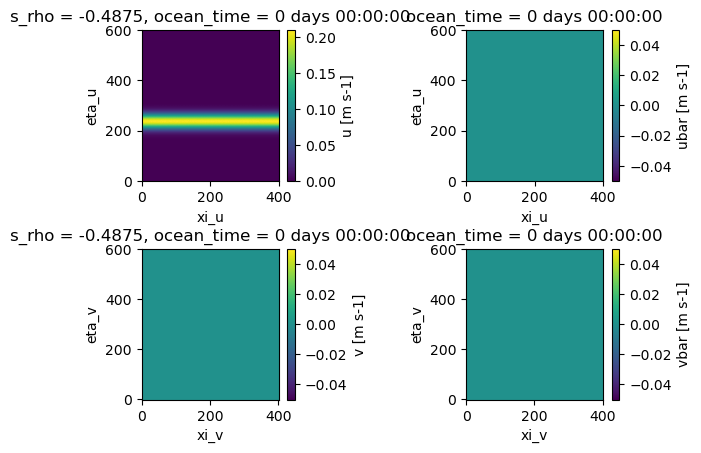

In [40]:
# Plot the currents in the original
fig, ax = plt.subplots(2, 2)

# u currents
og_ini.u[0,20,:,:].plot(ax=ax[0,0])

# ubar
og_ini.ubar[0,:,:].plot(ax=ax[0,1])

# v currents
og_ini.v[0,20,:,:].plot(ax=ax[1,0])

# vbar
og_ini.vbar[0,:,:].plot(ax=ax[1,1])

fig.subplots_adjust(hspace=0.45, wspace=0.89)

In [ ]:
# So let's leave v and vbar as 0, then make u a few things
# For starters, let's fix ubar to actually be calculated from u
# Calculate depth-averaged u current based on u

In [49]:
# Load in an output file to use xroms to get cell thickness

# Set the path to the output
path = '/pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_updated_scratch/roms_his_ice_500m_span_300km_w_dvd_u3c4_keps_v04_0001.nc'

# Open it using xroms
ds = xroms.open_netcdf(path)

# Get fancy grid info using xroms
model_output, xgrid = xroms.roms_dataset(ds, include_3D_metrics=True)

# Set the grid to this fancy grid
model_output.xroms.set_grid(xgrid) 

/global/homes/b/bundzis/.conda/envs/xroms/lib/python3.11/site-packages/xroms/xroms.py:865: SerializationWarning: Unable to decode time axis into full numpy.datetime64 objects, continuing using cftime.datetime objects instead, reason: dates prior reform date (1582-10-15). To silence this warning specify 'use_cftime=True'.
  ds = xr.open_dataset(file, chunks=chunks, **xrargs)
/global/homes/b/bundzis/.conda/envs/xroms/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg
/global/homes/b/bundzis/.conda/envs/xroms/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future

In [51]:
# See what all is included in this output
model_output

<xarray.Dataset> Size: 1TB
Dimensions:                     (tracer: 8, s_rho: 40, s_w: 41, eta_rho: 602,
                                 xi_rho: 402, xi_u: 401, eta_v: 601,
                                 ocean_time: 721)
Coordinates: (12/21)
  * s_rho                       (s_rho) float64 320B -0.9875 -0.9625 ... -0.0125
  * s_w                         (s_w) float64 328B -1.0 -0.975 ... -0.025 0.0
    x_rho                       (eta_rho, xi_rho) float64 2MB dask.array<chunksize=(602, 402), meta=np.ndarray>
    y_rho                       (eta_rho, xi_rho) float64 2MB dask.array<chunksize=(602, 402), meta=np.ndarray>
    x_u                         (eta_rho, xi_u) float64 2MB dask.array<chunksize=(602, 401), meta=np.ndarray>
    y_u                         (eta_rho, xi_u) float64 2MB dask.array<chunksize=(602, 401), meta=np.ndarray>
    ...                          ...
    z_w_u                       (ocean_time, s_w, eta_rho, xi_u) float64 57GB dask.array<chunksize=(1, 41, 602, 401), meta=np.ndarray>
    z_w_v                       (ocean_time, s_w, eta_v, xi_rho) float64 57GB dask.array<chunksize=(1, 41, 601, 402), meta=np.ndarray>
    z_w_psi                     (ocean_time, s_w, eta_v, xi_u) float64 57GB dask.array<chunksize=(1, 41, 601, 401), meta=np.ndarray>
    z_rho_u                     (ocean_time, s_rho, eta_rho, xi_u) float64 56GB dask.array<chunksize=(1, 40, 602, 401), meta=np.ndarray>
    z_rho_v                     (ocean_time, s_rho, eta_v, xi_rho) float64 56GB dask.array<chunksize=(1, 40, 601, 402), meta=np.ndarray>
    z_rho_psi                   (ocean_time, s_rho, eta_v, xi_u) float64 56GB dask.array<chunksize=(1, 40, 601, 401), meta=np.ndarray>
Dimensions without coordinates: tracer
Data variables: (12/152)
    ntimes                      int32 4B ...
    ndtfast                     int32 4B ...
    dt                          float64 8B ...
    dtfast                      float64 8B ...
    dstart                      object 8B ...
    nHIS                        int32 4B ...
    ...                          ...
    dz_w_u                      (ocean_time, s_w, eta_rho, xi_u) float64 57GB dask.array<chunksize=(1, 41, 602, 401), meta=np.ndarray>
    dz_v                        (ocean_time, s_rho, eta_v, xi_rho) float64 56GB dask.array<chunksize=(1, 40, 601, 402), meta=np.ndarray>
    dz_w_v                      (ocean_time, s_w, eta_v, xi_rho) float64 57GB dask.array<chunksize=(1, 41, 601, 402), meta=np.ndarray>
    dz_psi                      (ocean_time, s_rho, eta_v, xi_u) float64 56GB dask.array<chunksize=(1, 40, 601, 401), meta=np.ndarray>
    dz_w_psi                    (ocean_time, s_w, eta_v, xi_u) float64 57GB dask.array<chunksize=(1, 41, 601, 401), meta=np.ndarray>
    dA                          (eta_rho, xi_rho) float64 2MB dask.array<chunksize=(602, 402), meta=np.ndarray>
Attributes: (12/30)
    file:              /pscratch/sd/b/bundzis/Beaufort_ROMS_idealized_jet_upd...
    format:            netCDF-3 64bit offset file
    Conventions:       CF-1.4, SGRID-0.3
    type:              ROMS history file
    title:             Idealized Beaufort Sea Shelfbreak Jet
    var_info:          /global/homes/b/bundzis/Repos/roms/ROMS/External/varin...
    ...                ...
    compiler_command:  /opt/cray/pe/mpich/9.0.1/ofi/gnu/12.3/bin/mpif90
    compiler_flags:    -frepack-arrays -fallow-argument-mismatch        -O3 -...
    tiling:            16x32
    history:           ROMS, Version 4.3, Monday - July 13, 2026 -  2:41:00 PM
    ana_file:          /global/homes/b/bundzis/Repos/beaufort_jet/Bri_proj/Fu...
    CPP_options:       BEAUFORT_JET_ICE_W_DVD, ANA_BPFLUX, ANA_BSFLUX, ANA_BT...

In [50]:
# Pull out cell thickness on u grid to use
dz_u = model_output['dz_u']

In [61]:
print(np.shape(dz_u[0,:,:,:]))
print(np.shape(og_ini.u[0,:,:,:]))

(40, 602, 401)
(40, 602, 401)


In [62]:
# Calculate ubar
ini_ubar = ((np.sum((og_ini.u[0,:,:,:].values * dz_u[0,:,:,:].values), axis=0)) / xroms.to_u(model_output.h, xgrid))

/global/homes/b/bundzis/.conda/envs/xroms/lib/python3.11/site-packages/xgcm/grid_ufunc.py:832: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  out_dim: grid._ds.dims[out_dim] for arg in out_core_dims for out_dim in arg


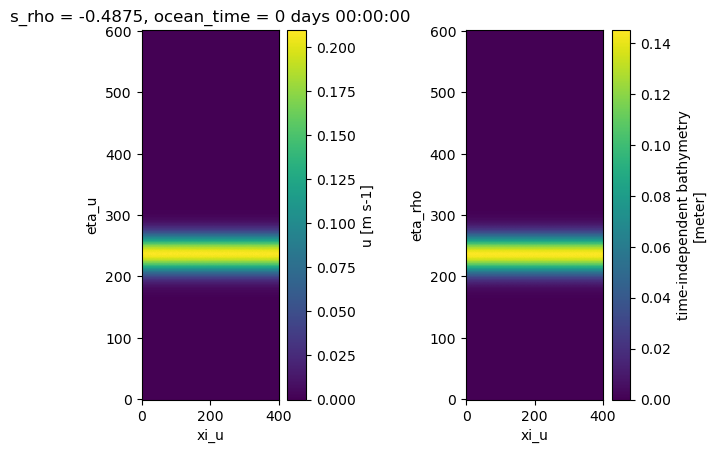

In [68]:
# Plot this to see if it worked
fig, ax = plt.subplots(1, 2)

# u currents
og_ini.u[0,20,:,:].plot(ax=ax[0])

# ubar
ini_ubar.plot(ax=ax[1])

fig.subplots_adjust(wspace=0.89)

In [69]:
# Now save this new ubar profile as the updated initial ubar, then 
# try a run with it 
# Make a ciopy of the original file
new_ini = og_ini.copy()

In [73]:
ini_ubar.shape

(602, 401)

In [74]:
# Make a new version of ubar that has the right shape
ini_ubar_fix = np.empty((1,602,401))

# Fill with the values
ini_ubar_fix[0,:,:] = ini_ubar

In [76]:
# Set the new bathymetry
new_ini['ubar'].values = ini_ubar_fix

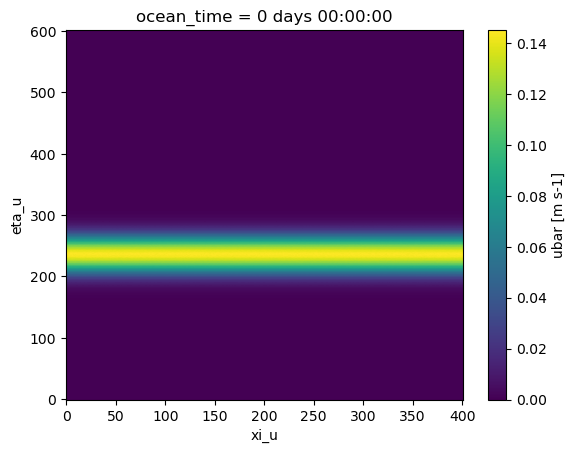

In [77]:
# Plot this to see if it worked

new_ini.ubar.plot()

In [78]:
# Save this new ini conds file
#new_ini.to_netcdf('/global/homes/b/bundzis/Projects/Beaufort_ROMS_idealized_jet_updated/Include/ini_ice_500m_span_300km_004_fixed_ubar.nc')

In [83]:
og_ini.z_rho[0,:,200,200].values

array([-62.00826784, -58.66797189, -55.51601549, -52.54731627,
       -49.75443155, -47.12826411, -44.65865086, -42.3348405 ,
       -40.1458706 , -38.08085689, -36.12920792, -34.28077793,
       -32.52596965, -30.85579735, -29.26191907, -27.73664549,
       -26.27293149, -24.86435545, -23.50509014, -22.18986823,
       -20.9139449 , -19.67305917, -18.46339531, -17.28154536,
       -16.12447318, -14.98948071, -13.87417648, -12.7764467 ,
       -11.69442871, -10.62648712,  -9.57119219,  -8.52730069,
        -7.49373886,  -6.46958756,  -5.45406937,  -4.44653758,
        -3.44646693,  -2.45344609,  -1.46717167,  -0.48744383])

In [89]:
# Load in to see if manual fix worked in make_ini.py
fixed_ini = xr.open_dataset('/global/u2/b/bundzis/Projects/Beaufort_ROMS_idealized_jet_updated/Include/ini_ice_500m_span_300km_004_TEST.nc')

/tmp/ipykernel_1628819/2264560309.py:2: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  fixed_ini = xr.open_dataset('/global/u2/b/bundzis/Projects/Beaufort_ROMS_idealized_jet_updated/Include/ini_ice_500m_span_300km_004_TEST.nc')


In [90]:
fixed_ini

<xarray.Dataset> Size: 420MB
Dimensions:             (s_rho: 40, eta_rho: 602, xi_rho: 402, ocean_time: 1,
                         eta_u: 602, xi_u: 401, eta_v: 601, xi_v: 402)
Coordinates:
  * s_rho               (s_rho) float64 320B -0.9875 -0.9625 ... -0.0375 -0.0125
  * xi_rho              (xi_rho) int64 3kB 0 1 2 3 4 5 ... 397 398 399 400 401
  * eta_rho             (eta_rho) int64 5kB 0 1 2 3 4 5 ... 597 598 599 600 601
  * ocean_time          (ocean_time) timedelta64[ns] 8B 00:00:00
Dimensions without coordinates: eta_u, xi_u, eta_v, xi_v
Data variables: (12/22)
    temp                (s_rho, eta_rho, xi_rho) float64 77MB ...
    salt                (s_rho, eta_rho, xi_rho) float64 77MB ...
    u                   (ocean_time, s_rho, eta_u, xi_u) float64 77MB ...
    v                   (ocean_time, s_rho, eta_v, xi_v) float64 77MB ...
    zeta                (ocean_time, eta_rho, xi_rho) float64 2MB ...
    ubar                (ocean_time, eta_u, xi_u) float64 2MB ...
    ...                  ...
    ice_sst             (ocean_time, eta_rho, xi_rho) float64 2MB ...
    ice_Sxx             (ocean_time, eta_rho, xi_rho) float64 2MB ...
    ice_Sxy             (ocean_time, eta_rho, xi_rho) float64 2MB ...
    ice_Syy             (ocean_time, eta_rho, xi_rho) float64 2MB ...
    Uice                (ocean_time, eta_u, xi_u) float64 2MB ...
    Vice                (ocean_time, eta_v, xi_v) float64 2MB ...
Attributes:
    type:         ROMS Ini file
    Description:  Initial conditions for ideal shelf; hc = 100, H_pyc = -50, ...
    Author:       Dylan Schlichting
    Created:      2026-09-07T06:29:58.253511

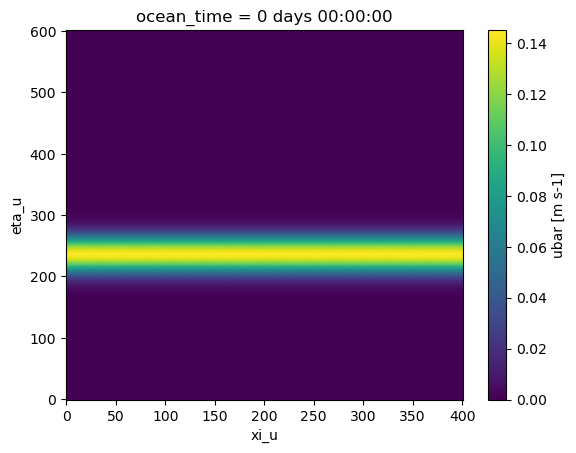

In [91]:
fixed_ini.ubar.plot()

<span style="color:olivedrab"> **Option 2** </span>   
Make them based on real data so would need to (potentially redownload HYCOM data), then choose conditions in October (maybe take the average over time? Then interpolate onto our grid?), then put those for salt, temp, u, v, ubar, vbar?

Or have other ways of taking one time stamp for conditions we like  

(I think this is the ultimate goal for another simulation but first do a simpler version to see if this even impacts the line formation)